<a href="https://colab.research.google.com/github/nagamamo/machine_learning_for_finance/blob/main/4_2_morkov_chain_monte_carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**4**　**マルコフ連鎖モンテカルロ法(MCMC)による株価の予測**

　本例では、マルコフ連鎖モンテカルロ法による株価予測手順を、日経平均株価の標本データを用いて説明します。ライブラリは、まずデータ管理、数値計算用にpandas、numpy、スクレイピングによる株価データ取得のためのpandas_datareader、統計分析のためのstatmodels、図表作成用のライブラリmatplotlib、事前分布に正規分布を用いるためにscipyのサブパッケージstatsからモジュールnormを読み込みます。

In [1]:
#[1]ライブラリの読み込み
import pandas as pd
import numpy as np
import pandas_datareader as data
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import t, norm #scipyのサブパッケージstatsからから正規分布モジュールnorm読み込み

　次に日経平均株価の日次データを取得します。本例では、pandasデータフレームの名称をNKXとして、2015年1月1日から2026年3月10日の日次データを取得します。得られた日次データから、終値（Close）を抽出して同様にデータフレームNKXの名称を上書きし、データフレーム内のデータ（コラム）名をCloseからnikkeiに修正します。尚、本例では、日次データを用います。

In [ ]:
#[2]株価データの取得
NKX=data.DataReader('^NKX','stooq',start="2015-01-01",end="2026-3-10").sort_values(by='Date',ascending=True)
nikkei=pd.DataFrame(NKX.Close)
nikkei = nikkei.rename(columns={'Close': 'nikkei'})
nikkei.head()

 　セル[3]で得られた日経平均株価日次データから、前日比のリターンを算出し、そして平均リターン、標準偏差（リスク）を順次算出します。続いて、mean_returnに±std_returnを加減することで、株価リターンの閾値上限・下限を算出します。

In [3]:
#[3]平均リターン・標準偏差の算出
nikkei['Daily Return'] = nikkei['nikkei'].pct_change() #前日比リターンの算出
mean_return = nikkei['Daily Return'].mean() #平均リターンの算出
std_return = nikkei['Daily Return'].std() #リターンの標準偏差の算出

In [4]:
#[4]株価リターン閾値の算出
up_thd = mean_return + std_return #リターン閾値上限
down_thd = mean_return - std_return #リターン閾値下限

　次に日次リターンの遷移過程を判定し、その結果を新たにデータフレームnikkei内に['Markov State']の列を新たに設けてその結果を書き込みます。

In [ ]:
#[5]遷移結果の判定
def classify_state(return_value, up_thresh, down_thresh): #3つの変数を定義
    if return_value > up_thresh: #リターン上限閾値を上回った場合
        return 'Up'
    elif return_value < down_thresh: #リターン下限閾値を下回った場合
        return 'Down'
    else: #リターン上下閾値内に留まった場合
        return 'Stagnant'
nikkei['Markov State'] = nikkei['Daily Return'].apply(lambda x: classify_state(x, up_thd, down_thd))#新たに列を挿入して結果を表記
nikkei.head()

　セル[5]において判定された[‘Markov State’]の列（ベクトル）を用いて、一期前の3種類の状態、Down、Stagnant、UpがDown、Stagnant、Upへ遷移する確率（頻度の比率）を算出して、この行列を生成します。

In [ ]:
#[6]遷移行列の算出
nikkei['Prev State'] = nikkei['Markov State'].shift(1) #nikkei['Markov State']列から前期状態の取得
transition_counts = pd.crosstab(nikkei['Prev State'], nikkei['Markov State']) #確率過程算出のための遷移行列の算出
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)
transition_matrix #遷移行列の表示

　セル[7]では、［6］において算出した遷移行列を用い、遷移が今後進んだとしても、これ以上は変化しない定常分布を反復計算により導出します。まず一行目では「定常状態」の定義式を与え、3行目で定義した定常分布の初期値からの遷移を乱数を発生させることで、収束計算を行います。これらを反復することで収束する値が、定常状態のDown、Stagnant、Upとなります。

In [ ]:
#[7]定常分布の導出
def find_equilibrium(transition_matrix): #定常分布の定義
    transition_matrix = transition_matrix + 1e-6 #特異行列回避の措置
    equilibrium = np.random.rand(transition_matrix.shape[0]) #定常状態の初期化
    equilibrium = equilibrium / np.sum(equilibrium) #定常分布の正則化
    while True: #収束計算
        new_equilibrium = np.dot(equilibrium, transition_matrix)
        if np.allclose(equilibrium, new_equilibrium):
            break
        equilibrium = new_equilibrium #算出結果を既存のデータフレームに上書き
    return equilibrium
equilibrium = find_equilibrium(transition_matrix) #定常分布の導出
print(equilibrium)

　[7]において定常状態のDown、Stagnant、Upが得られましたので、これを用いて[8]ではシミュレーションを実行します。手順は、5行目、6行目で指定する反復回数、予測期間を、事前分布から得られるパラメータを用いて、初期値を遷移させることから始めます。初期状態がDown、Stagnant、Upのいずれに遷移するのかは、予め遷移確率が与えられているため、これを用いて上昇・下落・横ばいのケース別に予測期間最終日（n_days）まで株価を遷移させます。これを指定した反復回数（n_simulations）回シミュレーションを実施することで、事後分布を得ます。事後分布の試算結果は、データフレームsimulated_pathsに収納して、n日後の株価の平均値、中央値、分布を算出して可視化します。

In [8]:
#[8]シミュレーションの実行
states=['Down','Stagnant','Up'] #定常分布データフレームの定義
params = t.fit(nikkei['Daily Return'].dropna()) #t分布からパラメータを取得
df_t, mu, sigma = params #事前分布より平均値・標準偏差を取得
initial_price = nikkei['nikkei'].iloc[-1] #直近の株価を初期値に指定
n_simulations = 5000  #反復回数の設定
n_days = 252  #将来予測期間の設定
initial_state = nikkei['Markov State'].iloc[-1] #初期状態を実績値から指定
initial_state_probabilities = [1 if state == initial_state else 0 for state in states] #初期状態の確率を指定
simulated_paths = []
for sim in range(n_simulations): #反復計算の実施
    simulated_returns = []
    current_state = np.random.choice(states, p=initial_state_probabilities)
    for day in range(n_days):
        # t分布に基づく遷移確率を用い現在の状態から次期の株価上昇・下落・横ばいケースの算出
        if current_state == "Up":
            daily_return = t.rvs(df_t, loc=mu + sigma, scale=sigma)
        elif current_state == "Down":
            daily_return = t.rvs(df_t, loc=mu - sigma, scale=sigma)
        else:
            daily_return = t.rvs(df_t, loc=mu, scale=sigma)
        simulated_returns.append(daily_return) #演算結果の格納
        current_state = np.random.choice(states, p=transition_matrix.loc[current_state].values) #次の状態へ遷移

    simulated_prices = initial_price * np.exp(np.cumsum(simulated_returns)) #株価初期値から次期株価の算出
    simulated_paths.append(simulated_prices) #算出結果の格納

　simulated_pathsに収納された試算結果の可視化は、下記によりグラフ化できます。まず一行目では、ndarray配列で保存されているsimulated_pathsの行列を転置して、pandasデータフレームに変換します。試算結果をpandasデータフレームに変換できれば後はmatplotlibにより可視化できます。

/tmp/ipykernel_226/3453880602.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


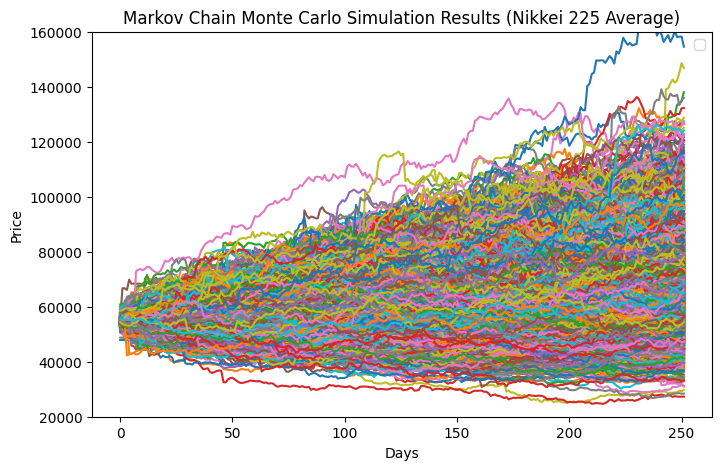

In [9]:
#[9]シミュレーション結果の可視化
simulated_paths_df = pd.DataFrame(simulated_paths).T #算出結果を行列転置してpandasデータフレーム形式へ変更
plt.figure(figsize=(8, 5))
plt.plot(simulated_paths_df)
ticker_symbol = 'Nikkei 225 Average'
plt.title(f"Markov Chain Monte Carlo Simulation Results ({ticker_symbol})")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.ylim(20000, 160000)
plt.show()

In [ ]:
simulated_paths_df

　最後に試算結果の記述統計量を算出します。本例は、日次データを用いて、252営業日後の株価を予測しています。以下では、この251列目のN種類（本例では5,000種類）の株価の試算結果を度数分布表を作成して、記述統計量を算出しています。マルコフ連鎖モンテカルロ法の試算結果を可視化した際の重要な点は、標準モンテカルロ法とは異なり、度数分布が左右非対称である点です。

[]

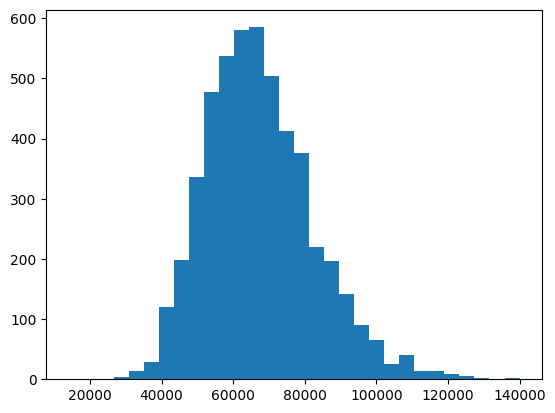

In [10]:
#[10]度数分布表の描画
nikkei_df=simulated_paths_df.loc[[251]]
nikkei_df_t=nikkei_df.T
plt.hist(nikkei_df_t,bins=30,range=(14000,140000))
plt.plot()

In [11]:
#[11]予測値の記述統計
print('平均値 {:.3f}'.format(nikkei_df_t[251].mean()))
print('中央値 {:.3f}'.format(nikkei_df_t[251].median()))
print('標準偏差 {:.3f}'.format(nikkei_df_t[251].std()))
print('最大値 {:.3f}'.format(nikkei_df_t[251].max()))
print('最小値 {:.3f}'.format(nikkei_df_t[251].min()))

平均値 67430.171
中央値 65984.848
標準偏差 15187.863
最大値 154573.263
最小値 27301.732
